<a href="https://colab.research.google.com/github/sammanfatima/Her-ML-Journey/blob/main/Discretization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Discretization
* Data discretization means converting continuous numerical values into groups

In [45]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

In [46]:
df = sns.load_dataset('titanic')

In [47]:
# impute missing values
df['age']= df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

In [48]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

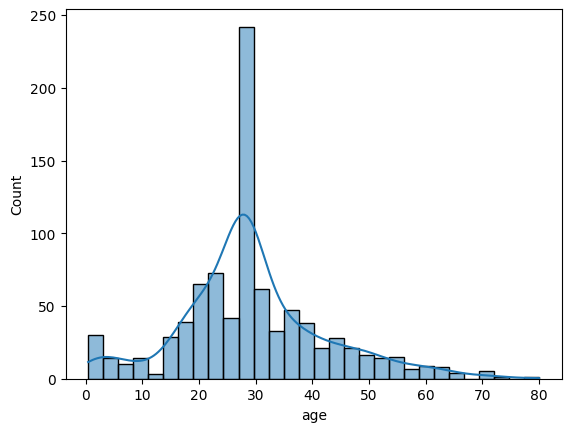

In [49]:
sns.histplot(df["age"], kde=True)

In [55]:
# age discretization
dis = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='uniform')
df['age_bin']= dis.fit_transform(df[['age']])
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.0


* dividing numerical data into 5 equal sized groups
* BinsDiscretizer → tool used to divide numerical values into groups.
* n_bins=5 → make 5 groups.
encode='ordinal' → give the groups numbers like 0, 1, 2, 3, 4.
* strategy='uniform' → make all groups have the same numerical range.

<Axes: xlabel='age', ylabel='Count'>

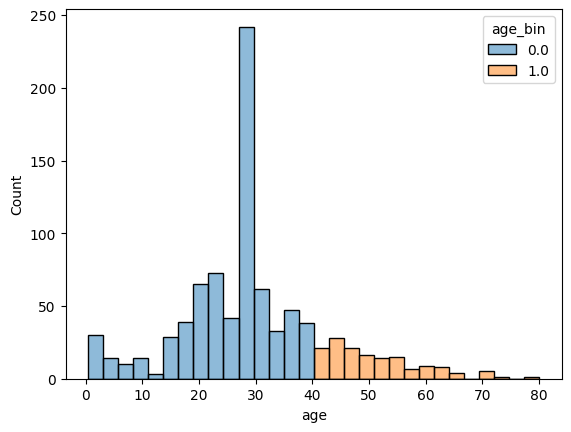

In [56]:
sns.histplot(df, x='age', hue= 'age_bin')

In [58]:
# age discretization usng quantile
dis = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df['age_bin']= dis.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.0


<Axes: xlabel='age', ylabel='Count'>

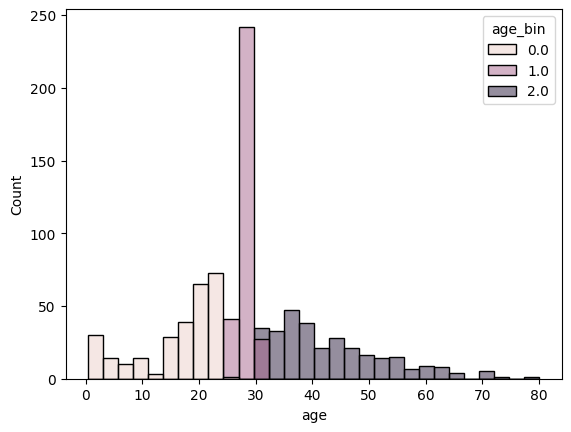

In [59]:
sns.histplot(df, x='age', hue= 'age_bin')

In [60]:
# age discretization using k-mean
dis = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df['age_bin']= dis.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.0


<Axes: xlabel='age', ylabel='Count'>

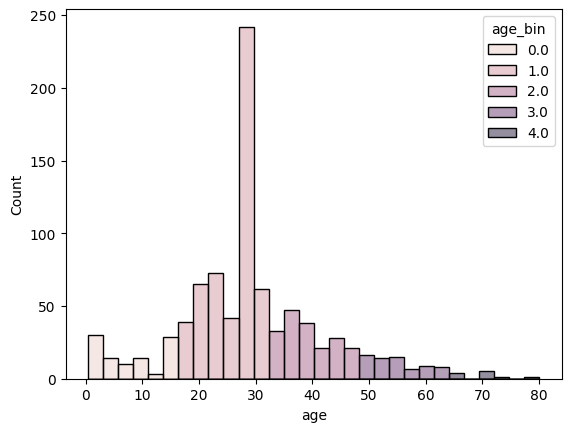

In [61]:
sns.histplot(df, x='age', hue= 'age_bin')

<Axes: xlabel='age', ylabel='Count'>

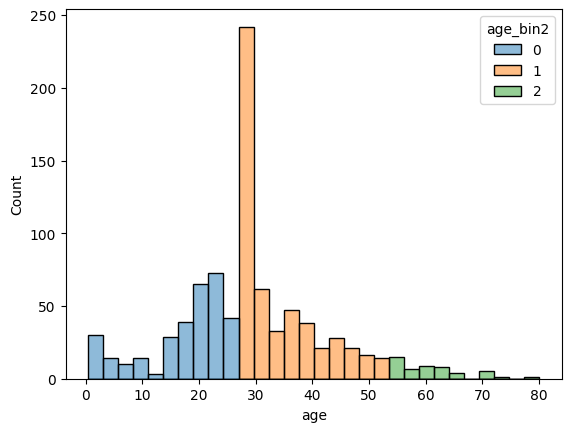

In [63]:
# pandas method for manual binning
df['age_bin2'] = pd.cut(df['age'], bins=3, labels=[0,1,2])
sns.histplot(df, x='age', hue='age_bin2')

<Axes: xlabel='age', ylabel='Count'>

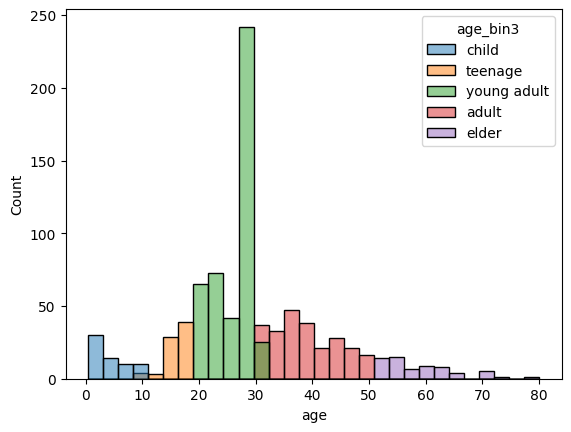

In [65]:
# define bins
bins = [0, 10, 18, 30, 50, 80]
labels = ['child', 'teenage', 'young adult', 'adult', 'elder']
df['age_bin3'] = pd.cut(df['age'], bins=bins, labels=labels)
sns.histplot(df, x= 'age', hue= 'age_bin3')